In [1]:
# Andrew Nowak

In [17]:
# Import Libraries 
import numpy as np 
import matplotlib.pyplot as plt 

In [62]:
# 1.1 - Build a Newton + Euler Solver 
# Define Variables 
steps = 1000
nsteps = 1000
# Define the Euler Newton function 
def euler_newton(force, times, x0, v0, m,dt):
    # Create arrays for x and v 
    x = []
    v = []

    # Store the initial conditions for the first elements 
    x.append(x0)
    v.append(v0)

    # For loop
    for i in range(steps - 1):

        a = force(times[i], x[i], v[i]) / m
        v.append(v[i] + a*dt)
        x.append(x[i] + v[i+1]*dt)

    return x, v
stop=10
times,dt = np.linspace(0, stop, nsteps,retstep=True)

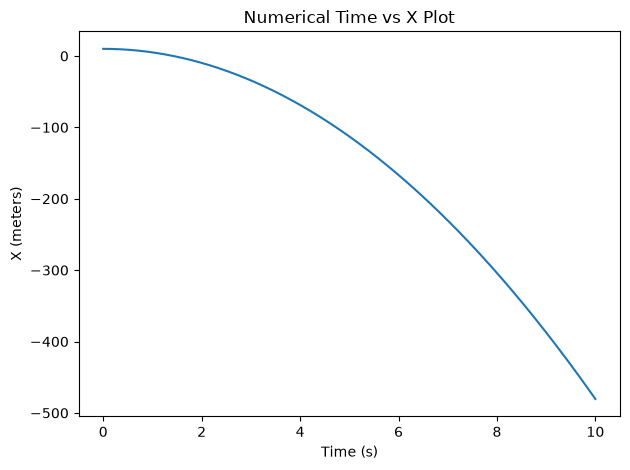

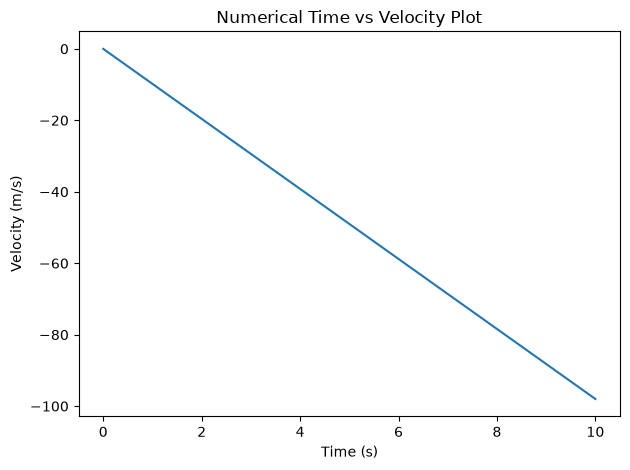

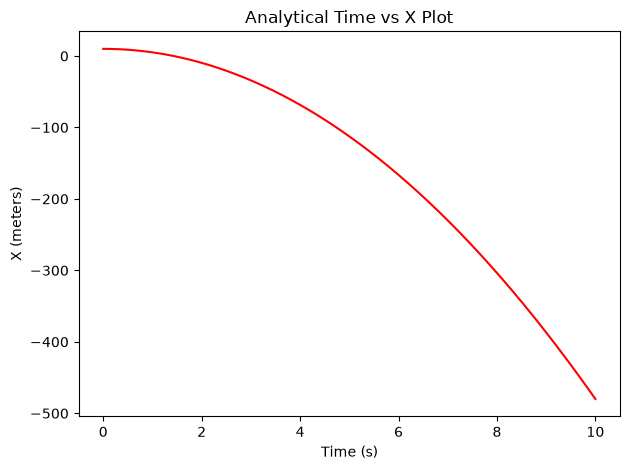

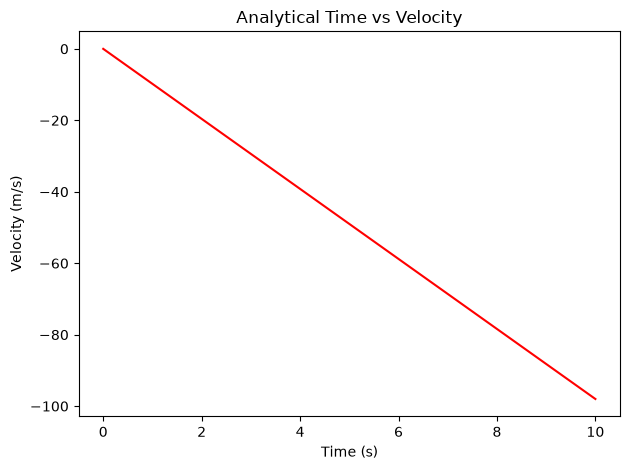

In [63]:
# 2.1 - Force Function for Gravity 

# Define our mass - 10g
m = 10

# Define the Function
def gravity(t, x, v):
    return (-1)*m*(9.8)

# Simulate an object dropped from test from a height of 10m, with time 10s
euler = euler_newton(gravity, times, 10, 0, 10,dt)
# Plot the numerical solutions
# Numerical solution for Time vs X (meters)
plt.plot(times, euler[0])
plt.xlabel("Time (s)")
plt.ylabel("X (meters)")
plt.title("Numerical Time vs X Plot")
plt.tight_layout()
plt.show() 

# Numerical solution for Time vs Velocity 
plt.plot(times, euler[1])
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Numerical Time vs Velocity Plot")
plt.tight_layout()
plt.show()

# Plot the analytical solutions
# Define analytical functions
def xt(x0, v0, t):
    return x0 + v0*t - (1/2)*(9.8)*t**2

def vt(v0, t):
    return v0 - (9.8)*t

# Call functions and graph analytical solutions 
xs = xt(10, 0, times)
vs = vt(0, times)

plt.plot(times, xs, color='red')
plt.xlabel("Time (s)")
plt.ylabel("X (meters)")
plt.title("Analytical Time vs X Plot")
plt.tight_layout()
plt.show()

plt.plot(times, vs, color='red')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Analytical Time vs Velocity")
plt.tight_layout()
plt.show()

# Conclusion 
# My numerical solutions via Euler method agree with the analytical solutions from the kinematics equations.
# I do receive the expected results from all the graphs.
# More time steps means the curves look smoother and more accurate

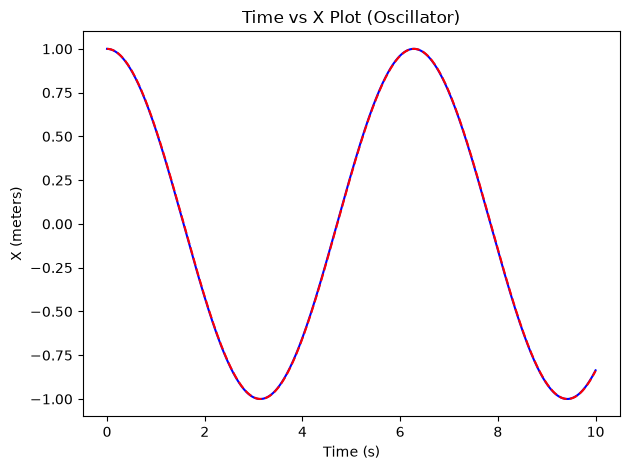

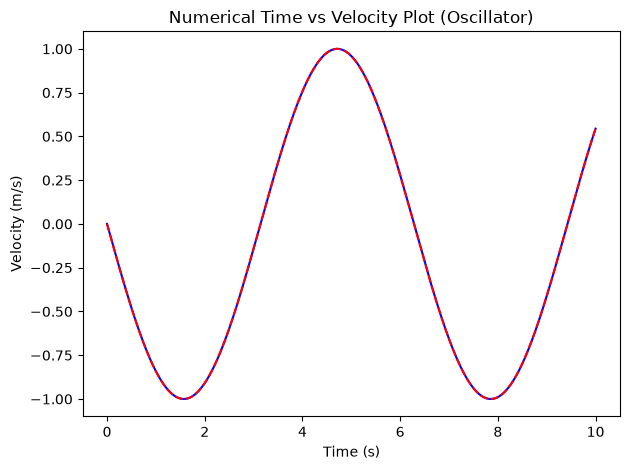

In [70]:
# 3 - A Simple Harmonic Oscillator

# Define a force function for a spring 
def spring_force(t, x, v,k=10):
    return (-1)*k*x

# Initialize values 
m = 10 # 1000g -> 1kg
k = 1
x0 = 1
v0 = 0

# Simulate the harmonic oscillator
euler = euler_newton(spring_force, times, x0, v0, m,dt)
# Plot the numerical and analytical  solutions
# Define analytical functions
def xt(t):
    return np.cos(t)

def vt(t):
    return (-1)*np.sin(t)

xs = xt(times)
vs = vt(times)

# Numerical solution for Time vs X (meters)
plt.plot(times, euler[0], color='blue')
plt.plot(times, xs, color='red', ls='--')
plt.xlabel("Time (s)")
plt.ylabel("X (meters)")
plt.title("Time vs X Plot (Oscillator)")
plt.tight_layout()
plt.show()

# Numerical solution for Time vs Velocity 
plt.plot(times, euler[1], color='blue')
plt.plot(times, vs, color='red', ls='--')
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.title("Numerical Time vs Velocity Plot (Oscillator)")
plt.tight_layout()
plt.show()

# Conclusion 
# The simulated oscillator does have the expected period 
# The numerical solution is identical to the analytical (red line is directly on top of blue line)
# More time steps gives more oscillations or waves